# SecureFlow Analytics - Cohort Analysis
## Phase 2: Retention Curves & Cohort Comparisons

**Goal:** Understand user retention patterns and identify high-value cohorts.

**Key Questions:**
1. What's the typical retention curve?
2. Which cohorts retain better (Q4 vs others)?
3. Does feature adoption improve retention?
4. Which channels bring highest LTV users?

---

In [1]:
import sys
sys.path.append('../src')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Custom modules
import config
from analytics.cohort_analysis import (
    calculate_retention_cohorts,
    pivot_retention_table,
    compare_feature_adoption_retention,
    calculate_ltv_by_cohort,
    compare_channel_cohorts
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Imports successful")

✅ Imports successful


In [2]:
# Connect to DuckDB
con = duckdb.connect()
print(f"📊 DuckDB connection established")

📊 DuckDB connection established


---
## 1. Weekly Retention Cohorts

Classic cohort analysis: how many users return each week?

In [3]:
# Calculate retention cohorts
retention_df = calculate_retention_cohorts(con, cohort_period='week', max_periods=8)
print("\n📊 Retention Data (first 20 rows):")
display(retention_df.head(20))


📊 Retention Data (first 20 rows):


,cohort_period,cohort_size,activity_period,periods_out,active_users,retention_pct
0,2024-01-01,648,2024-01-01,0,308,47.53
1,2024-01-01,648,2024-01-08,1,446,68.83
2,2024-01-01,648,2024-01-15,2,441,68.06
3,2024-01-01,648,2024-01-22,3,434,66.98
4,2024-01-01,648,2024-01-29,4,421,64.97
5,2024-01-01,648,2024-02-05,5,413,63.73
6,2024-01-01,648,2024-02-12,6,414,63.89
7,2024-01-01,648,2024-02-19,7,401,61.88
8,2024-01-01,648,2024-02-26,8,413,63.73
9,2024-01-08,691,2024-01-08,0,325,47.03


In [4]:
# Pivot into classic cohort table
retention_table = pivot_retention_table(retention_df)
print("\n📋 Weekly Retention Table:")
display(retention_table)


📋 Weekly Retention Table:


,Cohort Size,Week 0,Week 1,Week 2,Week 3,Week 4,Week 5,Week 6,Week 7,Week 8
cohort_period,,,,,,,,,,
2024-01-01,648,47.53,68.83,68.06,66.98,64.97,63.73,63.89,61.88,63.73
2024-01-08,691,47.03,67.58,65.85,66.86,66.43,65.12,63.53,63.39,63.24
2024-01-15,715,50.07,69.79,67.13,69.65,67.13,65.17,66.85,64.34,62.10
2024-01-22,705,48.94,64.96,67.66,65.53,66.52,65.11,60.99,64.40,62.27
2024-01-29,639,53.05,67.29,67.29,66.51,68.23,67.29,66.51,67.61,65.41
...,...,...,...,...,...,...,...,...,...,...
2025-04-28,661,49.62,67.93,65.66,68.99,69.29,68.38,67.02,62.78,64.30
2025-05-05,629,49.60,68.52,67.89,66.93,65.66,65.34,67.09,64.07,NaN
2025-05-12,708,48.16,67.66,68.93,66.24,68.50,65.11,63.28,NaN,NaN


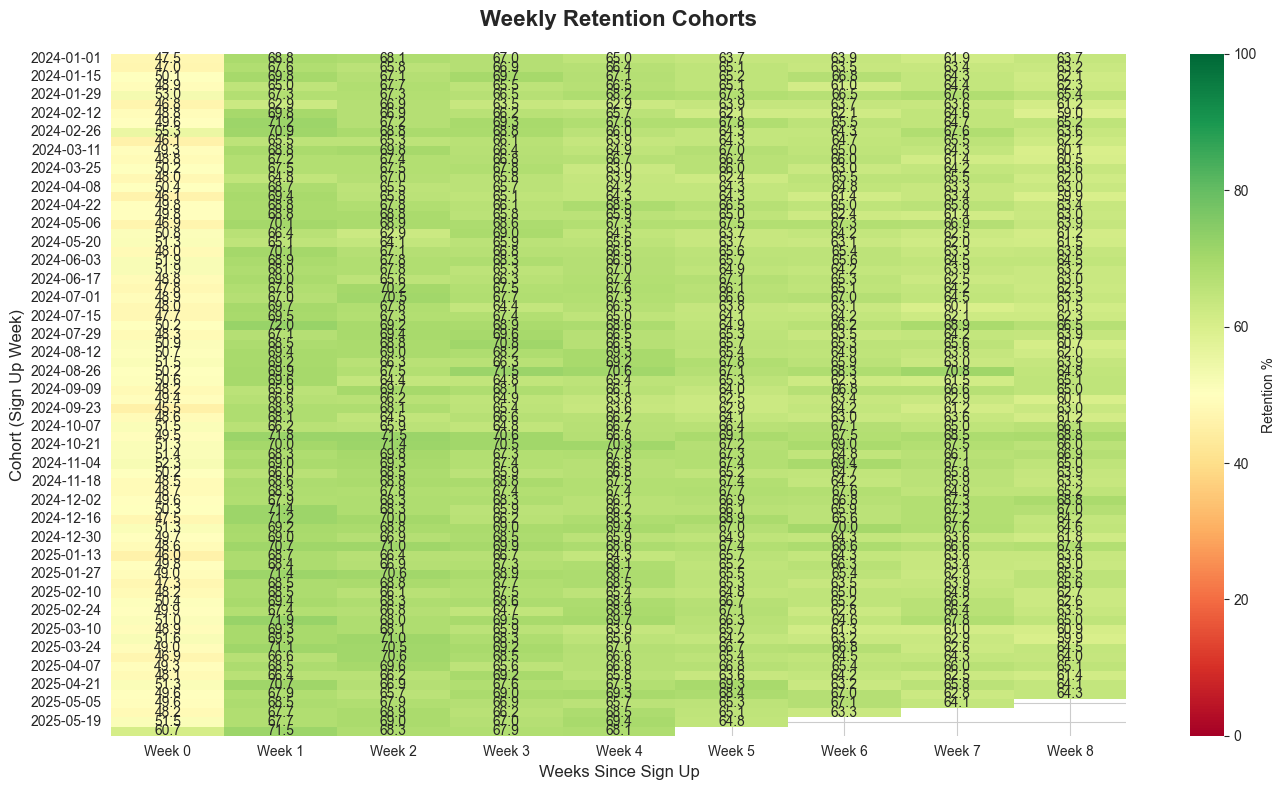

In [5]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Format cohort dates
retention_table_display = retention_table.copy()
retention_table_display.index = pd.to_datetime(retention_table_display.index).strftime('%Y-%m-%d')

# Select only retention columns (exclude Cohort Size)
retention_cols = [col for col in retention_table_display.columns if col.startswith('Week')]

sns.heatmap(
    retention_table_display[retention_cols],
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Retention %'},
    vmin=0,
    vmax=100,
    ax=ax
)

ax.set_title('Weekly Retention Cohorts', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Weeks Since Sign Up', fontsize=12)
ax.set_ylabel('Cohort (Sign Up Week)', fontsize=12)

plt.tight_layout()
plt.show()

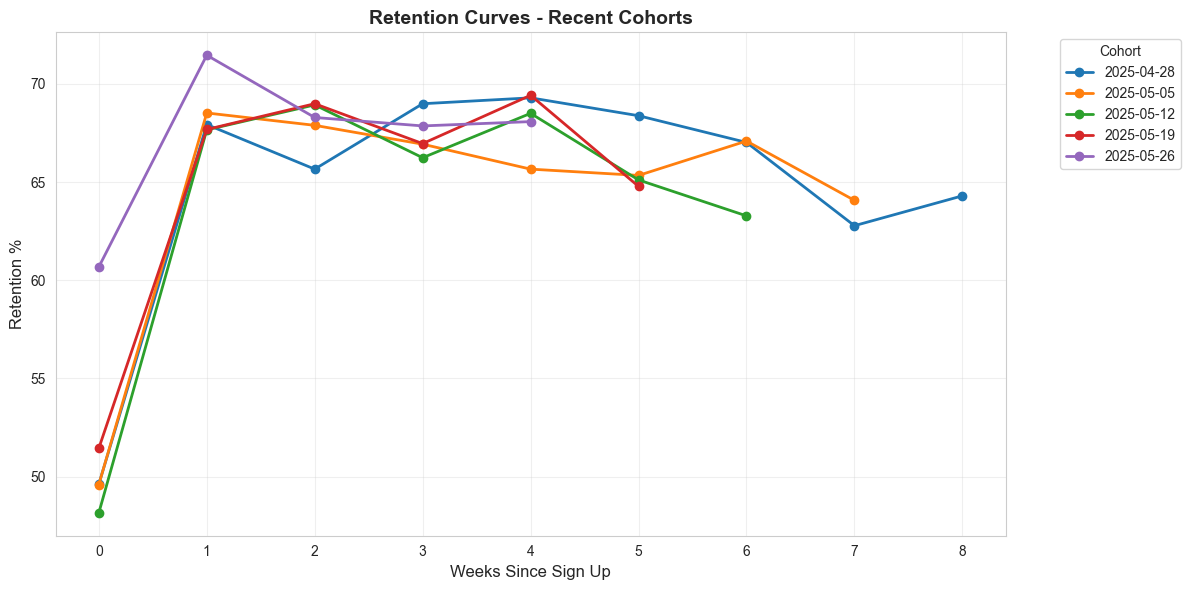

In [6]:
# Plot retention curves for recent cohorts
fig, ax = plt.subplots(figsize=(12, 6))

# Get last 5 cohorts
recent_cohorts = retention_df['cohort_period'].unique()[-5:]

for cohort in recent_cohorts:
    cohort_data = retention_df[retention_df['cohort_period'] == cohort]
    ax.plot(
        cohort_data['periods_out'],
        cohort_data['retention_pct'],
        marker='o',
        label=pd.to_datetime(cohort).strftime('%Y-%m-%d'),
        linewidth=2
    )

ax.set_xlabel('Weeks Since Sign Up', fontsize=12)
ax.set_ylabel('Retention %', fontsize=12)
ax.set_title('Retention Curves - Recent Cohorts', fontsize=14, fontweight='bold')
ax.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Feature Adoption Impact on Retention

**Hypothesis:** Users who enable real_time_protection have ~40% lower churn.

Let's test it!

In [7]:
# Compare retention: adopters vs non-adopters
feature_retention = compare_feature_adoption_retention(
    con,
    feature_name='real_time_protection',
    cohort_period='week',
    max_periods=8
)

print("\n🔒 real_time_protection Impact on Retention:")
display(feature_retention.head(20))


🔒 real_time_protection Impact on Retention:


,cohort_period,adoption_status,cohort_size,periods_out,active_users,retention_pct
0,2024-01-01,Adopted,495,0,233,47.07
1,2024-01-01,Adopted,495,1,348,70.30
2,2024-01-01,Adopted,495,2,341,68.89
3,2024-01-01,Adopted,495,3,339,68.48
4,2024-01-01,Adopted,495,4,334,67.47
5,2024-01-01,Adopted,495,5,324,65.45
6,2024-01-01,Adopted,495,6,334,67.47
7,2024-01-01,Adopted,495,7,321,64.85
8,2024-01-01,Adopted,495,8,336,67.88
9,2024-01-01,Not Adopted,153,0,75,49.02


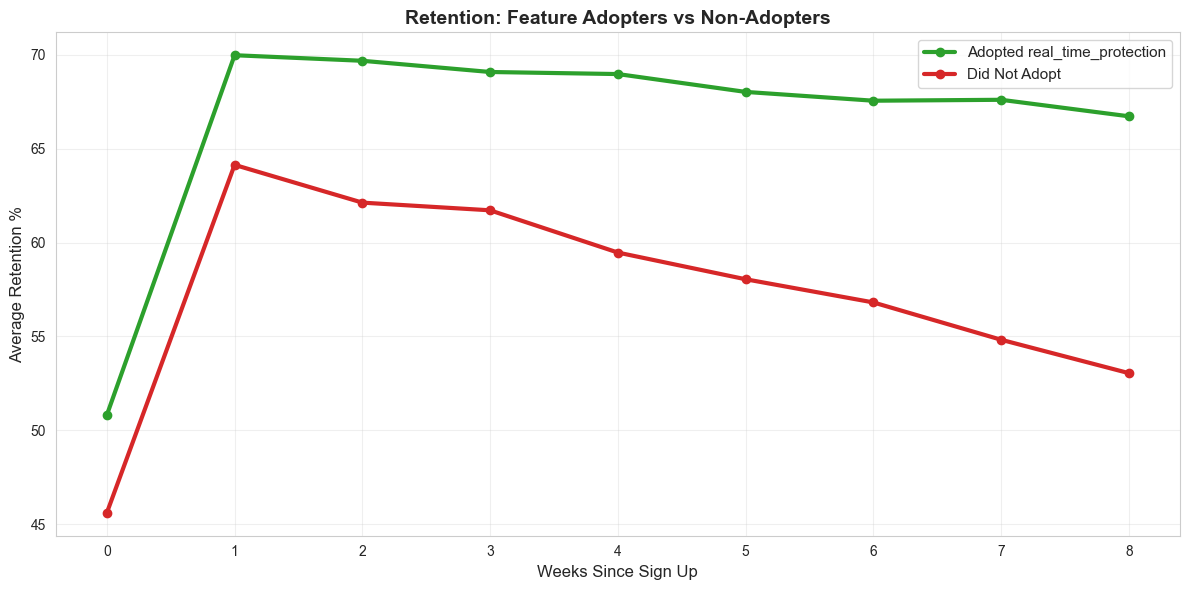


📊 Week 8 Retention:
  Adopted: 66.7%
  Not Adopted: 53.0%
  Churn Reduction: 25.8%


In [8]:
# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Aggregate across all cohorts
adopted = feature_retention[feature_retention['adoption_status'] == 'Adopted'].groupby('periods_out')['retention_pct'].mean()
not_adopted = feature_retention[feature_retention['adoption_status'] == 'Not Adopted'].groupby('periods_out')['retention_pct'].mean()

ax.plot(adopted.index, adopted.values, marker='o', linewidth=3, label='Adopted real_time_protection', color='#2ca02c')
ax.plot(not_adopted.index, not_adopted.values, marker='o', linewidth=3, label='Did Not Adopt', color='#d62728')

ax.set_xlabel('Weeks Since Sign Up', fontsize=12)
ax.set_ylabel('Average Retention %', fontsize=12)
ax.set_title('Retention: Feature Adopters vs Non-Adopters', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate churn reduction
week_8_adopted = adopted.iloc[-1]
week_8_not_adopted = not_adopted.iloc[-1]
churn_reduction = ((week_8_adopted - week_8_not_adopted) / week_8_not_adopted * 100)

print(f"\n📊 Week 8 Retention:")
print(f"  Adopted: {week_8_adopted:.1f}%")
print(f"  Not Adopted: {week_8_not_adopted:.1f}%")
print(f"  Churn Reduction: {churn_reduction:.1f}%")

---
## 3. Q4 Cohorts vs Others

**Hypothesis:** Q4 cohorts (Oct-Dec) have better retention.

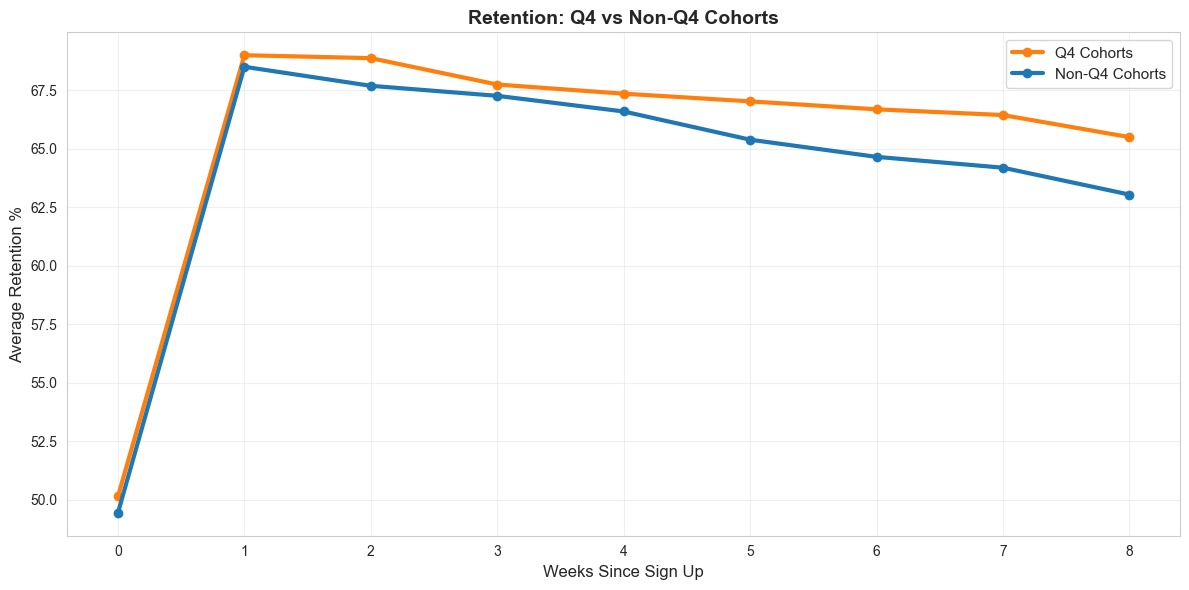


📊 Week 8 Retention:
  Q4 Cohorts: 65.5%
  Non-Q4 Cohorts: 63.0%
  Difference: 2.5 percentage points


In [9]:
# Compare Q4 vs non-Q4 cohorts
retention_df['cohort_date'] = pd.to_datetime(retention_df['cohort_period'])
retention_df['is_q4'] = retention_df['cohort_date'].dt.month.isin([10, 11, 12])

q4_retention = retention_df[retention_df['is_q4']].groupby('periods_out')['retention_pct'].mean()
non_q4_retention = retention_df[~retention_df['is_q4']].groupby('periods_out')['retention_pct'].mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(q4_retention.index, q4_retention.values, marker='o', linewidth=3, label='Q4 Cohorts', color='#ff7f0e')
ax.plot(non_q4_retention.index, non_q4_retention.values, marker='o', linewidth=3, label='Non-Q4 Cohorts', color='#1f77b4')

ax.set_xlabel('Weeks Since Sign Up', fontsize=12)
ax.set_ylabel('Average Retention %', fontsize=12)
ax.set_title('Retention: Q4 vs Non-Q4 Cohorts', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Week 8 Retention:")
print(f"  Q4 Cohorts: {q4_retention.iloc[-1]:.1f}%")
print(f"  Non-Q4 Cohorts: {non_q4_retention.iloc[-1]:.1f}%")
print(f"  Difference: {(q4_retention.iloc[-1] - non_q4_retention.iloc[-1]):.1f} percentage points")

---
## 4. Channel Comparison

Which acquisition channel brings the stickiest users?

In [10]:
# Compare retention by channel
channel_retention = compare_channel_cohorts(con, cohort_period='week', max_periods=8)

print("\n📱 Retention by Acquisition Channel:")
display(channel_retention)


📱 Retention by Acquisition Channel:


,acquisition_channel,cohort_period,weeks_out,cohort_size,active_users,retention_pct
0,affiliate,2024-01-01,0,61,36,59.02
1,affiliate,2024-01-01,1,61,40,65.57
2,affiliate,2024-01-01,2,61,39,63.93
3,affiliate,2024-01-01,3,61,41,67.21
4,affiliate,2024-01-01,4,61,39,63.93
...,...,...,...,...,...,...
4587,social_media,2025-05-26,0,88,47,53.41
4588,social_media,2025-05-26,1,88,62,70.45
4589,social_media,2025-05-26,2,88,60,68.18
4590,social_media,2025-05-26,3,88,55,62.50


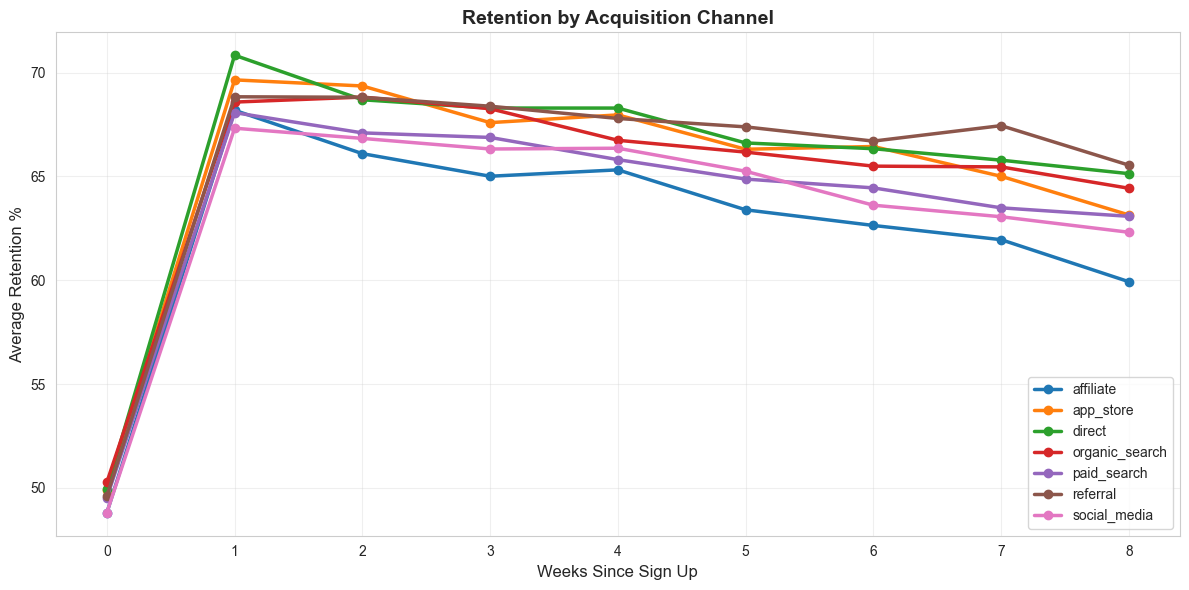

In [11]:
# Plot retention curves by channel
fig, ax = plt.subplots(figsize=(12, 6))

for channel in channel_retention['acquisition_channel'].unique():
    channel_data = channel_retention[channel_retention['acquisition_channel'] == channel]
    avg_retention = channel_data.groupby('weeks_out')['retention_pct'].mean()
    
    ax.plot(
        avg_retention.index,
        avg_retention.values,
        marker='o',
        linewidth=2.5,
        label=channel
    )

ax.set_xlabel('Weeks Since Sign Up', fontsize=12)
ax.set_ylabel('Average Retention %', fontsize=12)
ax.set_title('Retention by Acquisition Channel', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Lifetime Value (LTV) Analysis

Which cohorts generate the most revenue?

In [12]:
from analytics.funnel_analysis import * 
from utils import *
import config

# Check subscription plans
plans_check = execute_query(con, f"""
SELECT 
    plan,
    COUNT(*) as count,
    COUNT(DISTINCT user_id) as unique_users
FROM read_parquet('{config.SUBSCRIPTIONS_FILE}')
GROUP BY plan
ORDER BY count DESC
""")
print("Plan Types in Data:")
display(plans_check)

# Check date ranges
dates_check = execute_query(con, f"""
SELECT 
    plan,
    MIN(start_date) as earliest_start,
    MAX(start_date) as latest_start,
    COUNT(*) as total_subs,
    COUNT(CASE WHEN end_date IS NULL THEN 1 END) as active_subs,
    AVG(DATEDIFF('day', CAST(start_date AS TIMESTAMP), 
                    COALESCE(CAST(end_date AS TIMESTAMP), CURRENT_DATE))) as avg_days
FROM read_parquet('{config.SUBSCRIPTIONS_FILE}')
GROUP BY plan
""")
print("\nSubscription Date Ranges:")
display(dates_check)

# Check if users have subscriptions
user_sub_check = execute_query(con, f"""
SELECT 
    COUNT(DISTINCT u.user_id) as total_users,
    COUNT(DISTINCT s.user_id) as users_with_subs,
    ROUND(100.0 * COUNT(DISTINCT s.user_id) / COUNT(DISTINCT u.user_id), 2) as pct_with_subs
FROM read_parquet('{config.USERS_FILE}') u
LEFT JOIN read_parquet('{config.SUBSCRIPTIONS_FILE}') s
    ON u.user_id = s.user_id
""")
print("\nUser Subscription Coverage:")
display(user_sub_check)

Plan Types in Data:


,plan,count,unique_users
0,free,41218,41218
1,premium_monthly,5235,5235
2,premium_annual,3547,3547



Subscription Date Ranges:


,plan,earliest_start,latest_start,total_subs,active_subs,avg_days
0,free,2024-01-01,2025-05-30,41218,0,223.722573
1,premium_annual,2024-01-01,2025-05-30,3547,0,248.901889
2,premium_monthly,2024-01-01,2025-05-30,5235,0,239.843362



User Subscription Coverage:


,total_users,users_with_subs,pct_with_subs
0,50000,50000,100.0


In [18]:
# Simpler LTV calculation - just count active subscriptions
simple_ltv = execute_query(con, f"""
    WITH user_cohorts AS (
        SELECT 
            user_id,
            DATE_TRUNC('month', CAST(signup_date AS TIMESTAMP)) as cohort_period
        FROM read_parquet('{config.USERS_FILE}')
    ),
    user_plans AS (
        SELECT 
            s.user_id,
            s.plan,
            CASE s.plan
                WHEN 'free' THEN 0
                WHEN 'premium_monthly' THEN 9.99
                WHEN 'premium_annual' THEN 99.99
                ELSE 0
            END as monthly_value,
            CASE WHEN s.end_date IS NULL THEN 1 ELSE 0 END as is_active
        FROM read_parquet('{config.SUBSCRIPTIONS_FILE}') s
    )
    SELECT 
        uc.cohort_period,
        COUNT(DISTINCT uc.user_id) as cohort_size,
        COUNT(DISTINCT up.user_id) as users_with_subs,
        SUM(CASE WHEN up.is_active = 1 THEN up.monthly_value ELSE 0 END) as active_mrr,
        ROUND(AVG(up.monthly_value), 2) as avg_sub_value
    FROM user_cohorts uc
    LEFT JOIN user_plans up ON uc.user_id = up.user_id
    GROUP BY uc.cohort_period
    ORDER BY uc.cohort_period
""")

print("Simplified LTV Check:")
display(simple_ltv)

Simplified LTV Check:


,cohort_period,cohort_size,users_with_subs,active_mrr,avg_sub_value
0,2024-01-01,3054,3054,0.0,8.17
1,2024-02-01,2747,2747,0.0,7.77
2,2024-03-01,3035,3035,0.0,7.48
3,2024-04-01,2963,2963,0.0,7.66
4,2024-05-01,2911,2911,0.0,7.47
5,2024-06-01,2877,2877,0.0,8.21
6,2024-07-01,2966,2966,0.0,7.69
7,2024-08-01,3088,3088,0.0,8.39
8,2024-09-01,2988,2988,0.0,7.26
9,2024-10-01,3010,3010,0.0,9.71


In [14]:
# Calculate LTV by cohort
ltv_df = calculate_ltv_by_cohort(con, cohort_period='month')

print("\n💰 LTV by Monthly Cohort:")
display(ltv_df)


💰 LTV by Monthly Cohort:


,cohort_period,cohort_size,paying_users,avg_ltv,median_ltv_all,median_ltv_paying,total_revenue
0,2024-01-01,3054,516,94.59,0.0,119.88,288880.74
1,2024-02-01,2747,469,89.10,0.0,119.88,244756.53
2,2024-03-01,3035,516,85.88,0.0,119.88,260632.17
3,2024-04-01,2963,516,90.26,0.0,119.88,267431.22
4,2024-05-01,2911,491,85.67,0.0,119.88,249373.89
5,2024-06-01,2877,481,95.20,0.0,119.88,273885.03
6,2024-07-01,2966,498,82.13,0.0,109.89,243608.13
7,2024-08-01,3088,530,81.52,0.0,99.90,251729.46
8,2024-09-01,2988,469,63.39,0.0,89.91,189410.76
9,2024-10-01,3010,638,76.15,0.0,79.92,229211.19


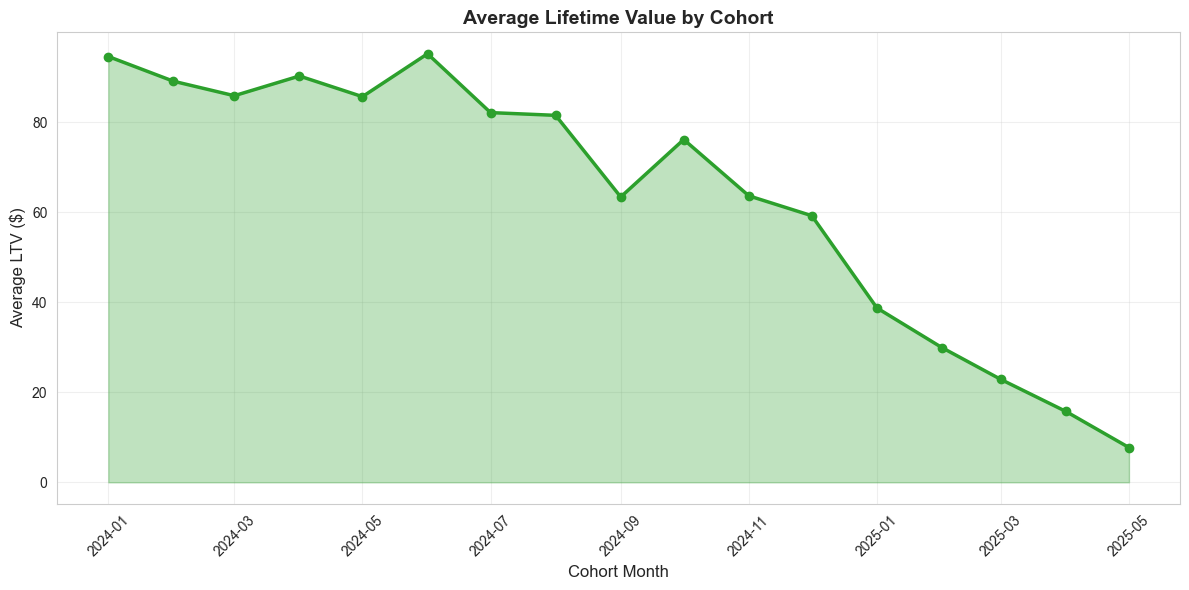

In [15]:
# Visualize LTV trend
fig, ax = plt.subplots(figsize=(12, 6))

ltv_df['cohort_date'] = pd.to_datetime(ltv_df['cohort_period'])
ltv_df = ltv_df.sort_values('cohort_date')

ax.plot(
    ltv_df['cohort_date'],
    ltv_df['avg_ltv'],
    marker='o',
    linewidth=2.5,
    color='#2ca02c',
    label='Average LTV'
)

ax.fill_between(
    ltv_df['cohort_date'],
    0,
    ltv_df['avg_ltv'],
    alpha=0.3,
    color='#2ca02c'
)

ax.set_xlabel('Cohort Month', fontsize=12)
ax.set_ylabel('Average LTV ($)', fontsize=12)
ax.set_title('Average Lifetime Value by Cohort', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# LTV by channel
query = """
WITH user_cohorts AS (
    SELECT 
        user_id,
        acquisition_channel
    FROM read_parquet('H:/My Drive/SecureFlow_Analytics/data/raw/users.parquet')
),
subscription_revenue AS (
    SELECT 
        s.user_id,
        COALESCE(SUM(
            CASE s.plan
                WHEN 'free' THEN 0
                WHEN 'premium_monthly' THEN 9.99
                WHEN 'premium_annual' THEN 99.99
            END * DATEDIFF('month', 
                CAST(s.start_date AS TIMESTAMP), 
                COALESCE(CAST(s.end_date AS TIMESTAMP), CURRENT_DATE)
            )
        ), 0) as total_revenue
    FROM read_parquet('H:/My Drive/SecureFlow_Analytics/data/raw/subscriptions.parquet') s
    GROUP BY s.user_id
)
SELECT 
    uc.acquisition_channel,
    COUNT(DISTINCT uc.user_id) as total_users,
    ROUND(AVG(COALESCE(sr.total_revenue, 0)), 2) as avg_ltv,
    ROUND(SUM(COALESCE(sr.total_revenue, 0)), 2) as total_revenue
FROM user_cohorts uc
LEFT JOIN subscription_revenue sr ON uc.user_id = sr.user_id
GROUP BY uc.acquisition_channel
ORDER BY avg_ltv DESC
"""

ltv_by_channel = con.execute(query).df()

print("\n💰 LTV by Acquisition Channel:")
display(ltv_by_channel)


💰 LTV by Acquisition Channel:


,acquisition_channel,total_users,avg_ltv,total_revenue
0,referral,6047,82.55,499198.59
1,paid_search,9884,72.59,717448.86
2,app_store,3881,63.83,247727.97
3,organic_search,12499,63.57,794509.56
4,direct,5068,57.77,292800.87
5,social_media,7566,53.95,408196.08
6,affiliate,5055,45.97,232390.80


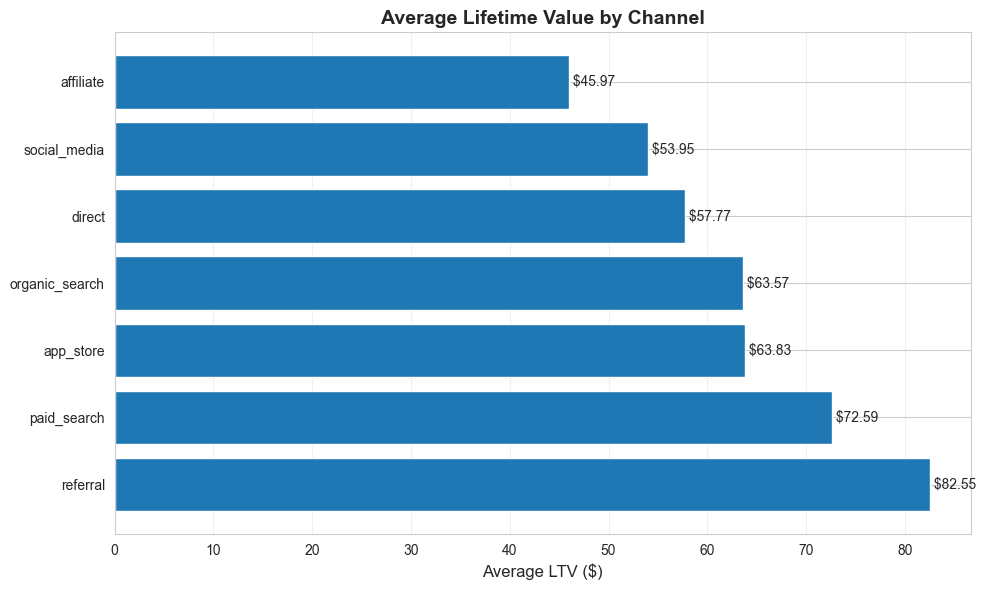

In [20]:
# Visualize channel LTV
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(ltv_by_channel['acquisition_channel'], ltv_by_channel['avg_ltv'])
ax.set_xlabel('Average LTV ($)', fontsize=12)
ax.set_title('Average Lifetime Value by Channel', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (channel, ltv) in enumerate(zip(ltv_by_channel['acquisition_channel'], ltv_by_channel['avg_ltv'])):
    ax.text(ltv, i, f' ${ltv:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Key Insights

**Summary of findings:**
1. Typical retention curve shape?
2. Feature adoption impact on churn?
3. Best performing cohorts?
4. Highest LTV channel?
5. Recommendations?

In [21]:
# Close connection
con.close()
print("\n✅ Analysis complete")


✅ Analysis complete
